# SupportSense — PyTorch Neural Text Classifier

This notebook develops a neural-network classifier for the BANKING77
customer-support intent classification problem using PyTorch.

The objective is to understand and implement the core deep-learning
training workflow rather than relying on a pretrained text classifier.

The workflow includes:

1. Text tokenisation
2. Vocabulary construction
3. Integer encoding
4. PyTorch Dataset and DataLoader
5. Embedding-based neural network
6. Forward propagation
7. Loss calculation
8. Backpropagation
9. Optimisation
10. Validation and checkpointing
11. Model evaluation
12. Comparison with the classical ML baseline

In [60]:
from pathlib import Path
from collections import Counter

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from sklearn.model_selection import (
    train_test_split,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

In [61]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [62]:
print(
    "PyTorch version:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

PyTorch version: 2.14.1+cu130
CUDA available: False


In [63]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


Using the reusable loader created

In [64]:
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(
        str(PROJECT_ROOT)
    )

In [65]:
from src.data.loader import (
    load_banking77_data,
)

In [66]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_df, test_df = (
    load_banking77_data(
        DATA_DIR
    )
)

print(
    "Original training:",
    train_df.shape
)

print(
    "Official test:",
    test_df.shape
)

Original training: (10003, 2)
Official test: (3080, 2)


In [67]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [68]:
print(
    train_df.columns.tolist()
)

print(
    "Number of intents:",
    train_df["category"].nunique()
)

['text', 'category']
Number of intents: 77


In [69]:
# Recreating the train/validation split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["category"],
)

In [70]:
print(
    "PyTorch training examples:",
    len(train_data)
)

print(
    "PyTorch validation examples:",
    len(val_data)
)

print(
    "Official test examples:",
    len(test_df)
)

PyTorch training examples: 8002
PyTorch validation examples: 2001
Official test examples: 3080


In [71]:
# Reset the DataFrame indexes
# Because train_test_split() preserves the old row indexes, they need to be cleaned up

train_data = (
    train_data
    .reset_index(drop=True)
)

val_data = (
    val_data
    .reset_index(drop=True)
)

test_data = (
    test_df
    .reset_index(drop=True)
)

In [72]:
train_data.head()

,text,category
0,How long do transfers take to show up in my ac...,balance_not_updated_after_bank_transfer
1,Why are fees charged for cash withdrawals? I w...,cash_withdrawal_charge
2,where can i have a virtual card,getting_virtual_card
3,how do I find the code to verify the top up card?,verify_top_up
4,Why was I unable to finish this transfer?,failed_transfer


In [73]:
# Creating a simple tokenizer
def tokenize(text):
    """
    Convert text into lowercase whitespace-separated tokens.
    """

    return str(text).lower().split()

In [74]:
example_text = (
    "My card has not arrived"
)

example_tokens = tokenize(
    example_text
)

print(example_tokens)

['my', 'card', 'has', 'not', 'arrived']


In [75]:
for text in train_data["text"].head(5):
    print("Original:")
    print(text)

    print("Tokens:")
    print(tokenize(text))

    print("-" * 60)

Original:
How long do transfers take to show up in my account?
Tokens:
['how', 'long', 'do', 'transfers', 'take', 'to', 'show', 'up', 'in', 'my', 'account?']
------------------------------------------------------------
Original:
Why are fees charged for cash withdrawals? I went to withdraw some money earlier today after shopping. There's a new fee that there.
Tokens:
['why', 'are', 'fees', 'charged', 'for', 'cash', 'withdrawals?', 'i', 'went', 'to', 'withdraw', 'some', 'money', 'earlier', 'today', 'after', 'shopping.', "there's", 'a', 'new', 'fee', 'that', 'there.']
------------------------------------------------------------
Original:
where can i have a virtual card
Tokens:
['where', 'can', 'i', 'have', 'a', 'virtual', 'card']
------------------------------------------------------------
Original:
how do I find the code to verify the top up card?
Tokens:
['how', 'do', 'i', 'find', 'the', 'code', 'to', 'verify', 'the', 'top', 'up', 'card?']
----------------------------------------------

In [76]:
# Building the vocabulary ONLY from training data
# This is crucial because building the vocabulary using 'train' + 'validation' + 'test' allows information from validation/test into model preparation
# Only 'train_data' will be used

token_counts = Counter()

for text in train_data["text"]:
    tokens = tokenize(text)

    token_counts.update(
        tokens
    )

In [77]:
token_counts.most_common(20)

[('i', 6671),
 ('my', 4517),
 ('to', 3235),
 ('a', 2851),
 ('the', 2833),
 ('is', 1888),
 ('can', 1461),
 ('do', 1402),
 ('card', 1309),
 ('it', 1285),
 ('how', 1239),
 ('for', 1225),
 ('what', 1094),
 ('and', 973),
 ('why', 966),
 ('you', 953),
 ('was', 878),
 ('have', 773),
 ('in', 767),
 ('not', 741)]

### Introducing special tokens
Two special vocabulary entries are needed.
<PAD>
<UNK>

<PAD> means padding
<UNK> means unknown word

Suppose the validation contains a word that isn't in the training, instead of crashing it will simply be mapped <UNK>


In [78]:
# Build the vocabulary
# Words appearing only once will initially be ignored

MIN_FREQUENCY = 2

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}


In [79]:
for token, count in token_counts.items():
    if count >= MIN_FREQUENCY:
        vocab[token] = len(vocab)

In [80]:
print(
    "Vocabulary size:",
    len(vocab)
)

Vocabulary size: 2189


In [81]:
# Inspecting the vocabulary

list(vocab.items())[:20]

[('<PAD>', 0),
 ('<UNK>', 1),
 ('how', 2),
 ('long', 3),
 ('do', 4),
 ('transfers', 5),
 ('take', 6),
 ('to', 7),
 ('show', 8),
 ('up', 9),
 ('in', 10),
 ('my', 11),
 ('account?', 12),
 ('why', 13),
 ('are', 14),
 ('fees', 15),
 ('charged', 16),
 ('for', 17),
 ('cash', 18),
 ('withdrawals?', 19)]

In [82]:
print(
    "PAD ID:",
    vocab[PAD_TOKEN]
)

print(
    "UNK ID:",
    vocab[UNK_TOKEN]
)

PAD ID: 0
UNK ID: 1


In [83]:
# Converting text to integere IDs
def encode_text(
    text,
    vocab,
):
    """
    Convert text into vocabulary IDs.
    """

    tokens = tokenize(text)

    token_ids = [
        vocab.get(
            token,
            vocab[UNK_TOKEN]
        )
        for token in tokens
    ]

    return token_ids

In [84]:
# Test
example_text = (
    "my card has not arrived"
)

encoded = encode_text(
    example_text,
    vocab,
)

print("Text:")
print(example_text)

print("\nTokens:")
print(tokenize(example_text))

print("\nToken IDs:")
print(encoded)

Text:
my card has not arrived

Tokens:
['my', 'card', 'has', 'not', 'arrived']

Token IDs:
[11, 39, 305, 152, 564]


In [85]:
# Testing an unknown word
unknown_example = (
    "gracercalifcinodlisticexpialidodbskncious card"
)

print(
    encode_text(
        unknown_example,
        vocab,
    )
)

[1, 39]


Since the absurd word isn't in the training vocabulary, it mapped to 1. 
Because:
vocab['<UNK>'] == 1

In [86]:
# choosing a maximum sequence length
train_lengths = (
    train_data["text"]
    .apply(tokenize)
    .apply(len)
)


In [87]:
train_lengths.describe()

count    8002.000000
mean       12.017871
std         7.996784
min         2.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        79.000000
Name: text, dtype: float64

In [88]:
# Inspect useful percentiles
for percentile in [
    90,
    95,
    99,
]:
    value = np.percentile(
        train_lengths,
        percentile
    )

    print(
        f"{percentile}th percentile: "
        f"{value:.0f} tokens"
    )


90th percentile: 22 tokens
95th percentile: 30 tokens
99th percentile: 44 tokens


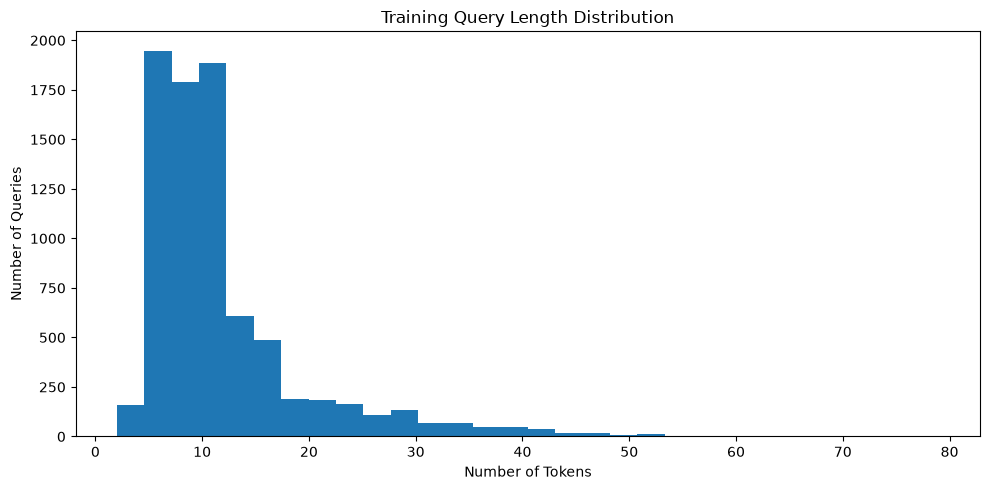

In [89]:
# Plotting the sequence-length distribution

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    train_lengths,
    bins=30
)

plt.title(
    "Training Query Length Distribution"
)

plt.xlabel(
    "Number of Tokens"
)

plt.ylabel(
    "Number of Queries"
)

plt.tight_layout()

plt.show()

In [90]:
# Choosing MAX_LENGTH
# from the output:
# 90th percentile: 22 tokens
# 95th percentile: 30 tokens
# 99th percentile: 44 tokens

# A MAX_LENGTH = 44 is defensible

MAX_LENGTH = 44

### Maximum Sequence Length

A fixed maximum sequence length is required so that examples can be
combined into batches.

The training-query length distribution was analysed before selecting
the maximum length. A value of ** 44 tokens** was selected
because it covers approximately ** 99% ** of the training
queries while avoiding unnecessary padding for the majority of short
messages.

Queries longer than this limit will be truncated, while shorter queries
will be padded.

In [91]:
# Creating padding and trucation

def pad_or_truncate(
    token_ids,
    max_length,
):
    """
    Pad or truncate token IDs to a fixed length.
    """

    token_ids = token_ids[
        :max_length
    ]

    padding_needed = (
        max_length
        - len(token_ids)
    )

    token_ids = token_ids + (
        [vocab[PAD_TOKEN]]
        * padding_needed
    )

    return token_ids

In [92]:
# Test

short_example = [
    10,
    20,
    30,
]

padded = pad_or_truncate(
    short_example,
    MAX_LENGTH,
)

print(padded)

print(
    "Length:",
    len(padded)
)

[10, 20, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 44


In [93]:
# Truncation test

long_example = list(
    range(
        MAX_LENGTH + 10
    )
)

truncated = pad_or_truncate(
    long_example,
    MAX_LENGTH,
)

print(
    "Original length:",
    len(long_example)
)

print(
    "After truncation:",
    len(truncated)
)

Original length: 54
After truncation: 44


In [94]:
# Encoding the 77 intent labels
# Currently the labels are strings, but PyTorch's classification loss expects numerical class IDs

intent_names = sorted(
    train_data[
        "category"
    ].unique()
)

intent_to_id = {
    intent: index
    for index, intent
    in enumerate(intent_names)
}

id_to_intent = {
    index: intent
    for intent, index
    in intent_to_id.items()
}

In [95]:
print(
    "Number of intents:",
    len(intent_to_id)
)

Number of intents: 77


In [96]:
# Inspect
list(
    intent_to_id.items()
)[:10]

[('Refund_not_showing_up', 0),
 ('activate_my_card', 1),
 ('age_limit', 2),
 ('apple_pay_or_google_pay', 3),
 ('atm_support', 4),
 ('automatic_top_up', 5),
 ('balance_not_updated_after_bank_transfer', 6),
 ('balance_not_updated_after_cheque_or_cash_deposit', 7),
 ('beneficiary_not_allowed', 8),
 ('cancel_transfer', 9)]

In [97]:
# Verifying all validation/test labels are known
train_intents = set(
    train_data["category"]
)

val_intents = set(
    val_data["category"]
)

test_intents = set(
    test_data["category"]
)

print(
    "Validation labels missing from training:",
    val_intents - train_intents
)

print(
    "Test labels missing from training:",
    test_intents - train_intents
)

Validation labels missing from training: set()
Test labels missing from training: set()


In [98]:
# Create the custom Dataset
class BankingDataset(Dataset):
    def __init__(
        self,
        dataframe,
        vocab,
        intent_to_id,
        max_length,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.vocab = vocab
        self.intent_to_id = (
            intent_to_id
        )

        self.max_length = (
            max_length
        )

    def __len__(self):
        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.dataframe.iloc[
            index
        ]

        text = row["text"]
        intent = row["category"]

        token_ids = encode_text(
            text,
            self.vocab,
        )

        token_ids = pad_or_truncate(
            token_ids,
            self.max_length,
        )

        label_id = (
            self.intent_to_id[
                intent
            ]
        )

        input_tensor = torch.tensor(
            token_ids,
            dtype=torch.long,
        )

        label_tensor = torch.tensor(
            label_id,
            dtype=torch.long,
        )

        return (
            input_tensor,
            label_tensor,
        )

In [99]:
# Create the training and validation datasets

train_dataset = BankingDataset(
    dataframe=train_data,
    vocab=vocab,
    intent_to_id=intent_to_id,
    max_length=MAX_LENGTH,
)

val_dataset = BankingDataset(
    dataframe=val_data,
    vocab=vocab,
    intent_to_id=intent_to_id,
    max_length=MAX_LENGTH,
)


In [100]:
# Inspect one Dataset example

input_tensor, label_tensor = (
    train_dataset[0]
)

print(
    "Input tensor:"
)

print(
    input_tensor
)

print(
    "\nInput shape:",
    input_tensor.shape
)

print(
    "\nLabel tensor:",
    label_tensor
)

print(
    "\nIntent:",
    id_to_intent[
        label_tensor.item()
    ]
)

Input tensor:
tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0])

Input shape: torch.Size([44])

Label tensor: tensor(6)

Intent: balance_not_updated_after_bank_transfer


In [101]:
# Create DataLoaders
# shuffle=True for training because the model shouldn't repeatedly see examples in exactly the same order
# shuffle=False for validation because only evaluation is being done. Random order provides no benefit

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [102]:
# Inspect one batch

batch_inputs, batch_labels = next(
    iter(train_loader)
)

print(
    "Input batch shape:",
    batch_inputs.shape
)

print(
    "Label batch shape:",
    batch_labels.shape
)

Input batch shape: torch.Size([64, 44])
Label batch shape: torch.Size([64])


### Build the PyTorch Neural Network

In [103]:
# Define the model settings
VOCAB_SIZE = len(vocab)
NUM_CLASSES = len(intent_to_id)

EMBEDDING_DIM = 128
DROPOUT_RATE = 0.3

print("Vocabulary size:", VOCAB_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Embedding dimension:", EMBEDDING_DIM)

Vocabulary size: 2189
Number of classes: 77
Embedding dimension: 128


128 is the initial embedding size. It is a development choice, not something proven as optimal

In [104]:
# Build the neural network
class IntentClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_classes,
        padding_idx,
        dropout_rate,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx,
        )

        self.dropout = nn.Dropout(
            p=dropout_rate
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes,
        )

    def forward(self, input_ids):
        embeddings = self.embedding(
            input_ids
        )

        mask = (
            input_ids != vocab[PAD_TOKEN]
        ).unsqueeze(-1)

        masked_embeddings = (
            embeddings * mask
        )

        summed_embeddings = (
            masked_embeddings.sum(dim=1)
        )

        token_counts = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        pooled = (
            summed_embeddings
            / token_counts
        )

        pooled = self.dropout(
            pooled
        )

        logits = self.classifier(
            pooled
        )

        return logits

In [105]:
# Instantiate the model
model = IntentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=vocab[PAD_TOKEN],
    dropout_rate=DROPOUT_RATE,
)

model = model.to(device)

print(model)

IntentClassifier(
  (embedding): Embedding(2189, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=77, bias=True)
)


In [106]:
# Count trainable parameters
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 290,125
Trainable parameters: 290,125


In [107]:
# Performing ONE forward pass
# making sure data can actually flow through the network before training at all
 
batch_inputs = batch_inputs.to(
    device
)

batch_labels = batch_labels.to(
    device
)

In [108]:
model.eval()

with torch.no_grad():
    logits = model(
        batch_inputs
    )

print(
    "Logits shape:",
    logits.shape
)

Logits shape: torch.Size([64, 77])


In [109]:
# To get the predicted class
predicted_class_ids = (
    logits.argmax(dim=1)
)

print(
    predicted_class_ids[:10]
)

tensor([56, 15, 26, 51, 32, 24, 11, 75,  2, 66])


In [110]:
# converting one into a readable intent
first_prediction_id = (
    predicted_class_ids[0].item()
)

print(
    id_to_intent[
        first_prediction_id
    ]
)

top_up_by_bank_transfer_charge


In [111]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

In [112]:
# Calculate one loss
loss = criterion(
    logits,
    batch_labels,
)

print(
    "Loss:",
    loss.item()
)

Loss: 4.386929988861084


In [113]:
# Define the optimizer
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [114]:
# Performing one manual training step
model.train()

optimizer.zero_grad()

logits = model(
    batch_inputs
)

loss = criterion(
    logits,
    batch_labels
)

loss.backward()

optimizer.step()

print(
    "Training step loss:",
    loss.item()
)

Training step loss: 4.402130126953125


In [115]:
# Reinitialize the model
torch.manual_seed(
    RANDOM_STATE
)

model = IntentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=vocab[PAD_TOKEN],
    dropout_rate=DROPOUT_RATE,
).to(device)

In [116]:
# recreate the optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [117]:
# Build the training function
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    for inputs, labels in data_loader:
        inputs = inputs.to(
            device
        )

        labels = labels.to(
            device
        )

        optimizer.zero_grad()

        logits = model(
            inputs
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * inputs.size(0)
        )

        predictions = (
            logits.argmax(dim=1)
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .tolist()
        )

        all_labels.extend(
            labels
            .detach()
            .cpu()
            .tolist()
        )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return (
        average_loss,
        accuracy,
        macro_f1,
    )

predictions
.detach()
.cpu()
.tolist()

simply means:

PyTorch computation graph
        ↓
detach
        ↓
move to CPU
        ↓
convert to Python list

So the function works whether CPU or GPU is used

In [118]:
# Build the validation function
# Validation is different. Backpropagating and updating weights shouldn't be done during validation

def evaluate_model(
    model,
    data_loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for inputs, labels in data_loader:
            inputs = inputs.to(
                device
            )

            labels = labels.to(
                device
            )

            logits = model(
                inputs
            )

            loss = criterion(
                logits,
                labels
            )

            total_loss += (
                loss.item()
                * inputs.size(0)
            )

            predictions = (
                logits.argmax(dim=1)
            )

            all_predictions.extend(
                predictions
                .cpu()
                .tolist()
            )

            all_labels.extend(
                labels
                .cpu()
                .tolist()
            )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return (
        average_loss,
        accuracy,
        macro_f1,
    )

In [119]:
# Testing ONE full training epoch
train_loss, train_accuracy, train_f1 = (
    train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )
)

In [120]:
print(
    f"Training Loss: "
    f"{train_loss:.4f}"
)

print(
    f"Training Accuracy: "
    f"{train_accuracy:.4f}"
)

print(
    f"Training Macro F1: "
    f"{train_f1:.4f}"
)

Training Loss: 4.1501
Training Accuracy: 0.0930
Training Macro F1: 0.0800


In [121]:
# Run validation
val_loss, val_accuracy, val_f1 = (
    evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device,
    )
)

In [122]:
print(
    f"Validation Loss: "
    f"{val_loss:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{val_f1:.4f}"
)

Validation Loss: 3.9099
Validation Accuracy: 0.2604
Validation Macro F1: 0.2197


In [123]:
# Reinitializing again before the real training run
# Because the previous epoch was a test, reseting the model once more

torch.manual_seed(
    RANDOM_STATE
)

model = IntentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=vocab[PAD_TOKEN],
    dropout_rate=DROPOUT_RATE,
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [127]:
# Set the number of epochs
NUM_EPOCHS = 20

In [128]:
# Prepare training history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
}

In [129]:
# Prepare checkpointing

PYTORCH_MODEL_DIR = (
    PROJECT_ROOT / "models"
)

PYTORCH_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_MODEL_PATH = (
    PYTORCH_MODEL_DIR
    / "supportsense_pytorch.pt"
)

best_val_f1 = -1.0
best_epoch = 0

In [130]:
# Build the full training loop
for epoch in range(
    1,
    NUM_EPOCHS + 1,
):
    train_loss, train_accuracy, train_f1 = (
        train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )
    )

    val_loss, val_accuracy, val_f1 = (
        evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
        )
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["train_f1"].append(
        train_f1
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_f1"].append(
        val_f1
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_accuracy:.4f} | "
        f"Val F1:   {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH,
        )

        print(
            "Saved new best model."
        )

    print("-" * 70)

Epoch 01/20
Train Loss: 4.1501 | Train Acc: 0.0930 | Train F1: 0.0800
Val Loss:   3.9099 | Val Acc:   0.2604 | Val F1:   0.2197
Saved new best model.
----------------------------------------------------------------------
Epoch 02/20
Train Loss: 3.6775 | Train Acc: 0.3092 | Train F1: 0.2717
Val Loss:   3.4705 | Val Acc:   0.3963 | Val F1:   0.3485
Saved new best model.
----------------------------------------------------------------------
Epoch 03/20
Train Loss: 3.2261 | Train Acc: 0.4176 | Train F1: 0.3774
Val Loss:   3.0430 | Val Acc:   0.4688 | Val F1:   0.4272
Saved new best model.
----------------------------------------------------------------------
Epoch 04/20
Train Loss: 2.8047 | Train Acc: 0.4920 | Train F1: 0.4547
Val Loss:   2.6557 | Val Acc:   0.5462 | Val F1:   0.5080
Saved new best model.
----------------------------------------------------------------------
Epoch 05/20
Train Loss: 2.4302 | Train Acc: 0.5572 | Train F1: 0.5275
Val Loss:   2.3264 | Val Acc:   0.5867 | Val F

In [131]:
# Display the best epoch
print(
    "Best epoch:",
    best_epoch
)

print(
    f"Best validation Macro F1: "
    f"{best_val_f1:.4f}"
)

print(
    "Checkpoint:",
    BEST_MODEL_PATH
)

Best epoch: 20
Best validation Macro F1: 0.7979
Checkpoint: /workspaces/supportsense-ml/models/supportsense_pytorch.pt


In [132]:
# Turn history into a DataFrame
history_df = pd.DataFrame({
    "epoch": range(
        1,
        NUM_EPOCHS + 1
    ),
    **history,
})

history_df.round(4)

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
0,1,4.1501,0.0930,0.0800,3.9099,0.2604,0.2197
1,2,3.6775,0.3092,0.2717,3.4705,0.3963,0.3485
2,3,3.2261,0.4176,0.3774,3.0430,0.4688,0.4272
3,4,2.8047,0.4920,0.4547,2.6557,0.5462,0.5080
4,5,2.4302,0.5572,0.5275,2.3264,0.5867,0.5600
5,6,2.1218,0.6041,0.5785,2.0599,0.6287,0.6106
6,7,1.8776,0.6468,0.6271,1.8453,0.6592,0.6461
7,8,1.6711,0.6795,0.6630,1.6700,0.6852,0.6751
8,9,1.4992,0.7067,0.6945,1.5266,0.7056,0.6986
9,10,1.3619,0.7309,0.7245,1.4090,0.7161,0.7090


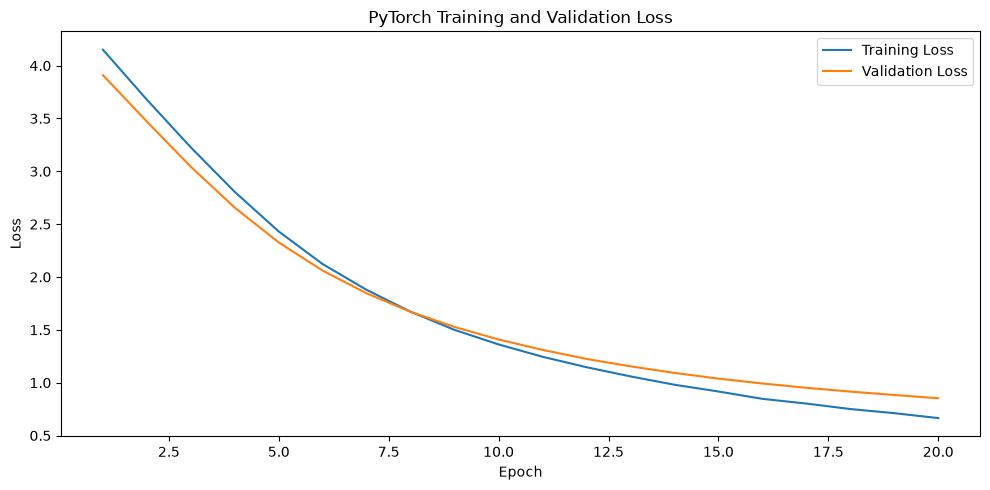

In [133]:
# Plot training and validation loss
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "PyTorch Training and Validation Loss"
)
plt.legend()
plt.tight_layout()

plt.show()

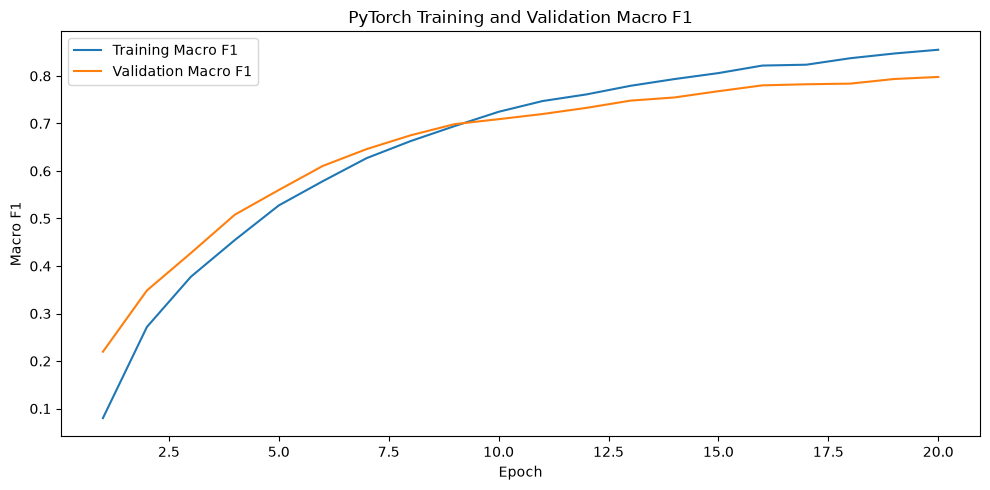

In [134]:
# Plot Macro F1
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    label="Training Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title(
    "PyTorch Training and Validation Macro F1"
)
plt.legend()
plt.tight_layout()

plt.show()

In [135]:
# Loading the BEST model

# Load the checkpoint:
best_model = IntentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=vocab[PAD_TOKEN],
    dropout_rate=DROPOUT_RATE,
).to(device)

In [136]:
best_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
    )
)

best_model.eval()

print(
    "Best checkpoint loaded."
)

Best checkpoint loaded.


In [137]:
# Re-evaluating the best checkpoint
best_val_loss, best_val_accuracy, best_val_f1_check = (
    evaluate_model(
        model=best_model,
        data_loader=val_loader,
        criterion=criterion,
        device=device,
    )
)

In [138]:
print("BEST PYTORCH VALIDATION RESULTS")
print("--------------------------------")
print(
    f"Loss:     {best_val_loss:.4f}"
)
print(
    f"Accuracy: {best_val_accuracy:.4f}"
)
print(
    f"Macro F1: {best_val_f1_check:.4f}"
)

BEST PYTORCH VALIDATION RESULTS
--------------------------------
Loss:     0.8530
Accuracy: 0.7971
Macro F1: 0.7979


The F1 matches the best checkpoint seen during training, subject to tiny numerical differences

### Comparing PyTorch against SVM validation benchmark

Original untuned SVM validation result was:
Accuracy: 0.8806
Macro F1: 0.8819

But because hyperparameter tuning was subsequently performed, proper comparison should use actual winning SVM validation metrics, not automatically 0.8819

In [139]:
# BEST SVM CONFIGURATION
SVM_VALIDATION_ACCURACY = 0.8846
SVM_VALIDATION_F1 = 0.8853

In [140]:
# Putting the real values

validation_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Linear SVM",
        "Accuracy": SVM_VALIDATION_ACCURACY,
        "Macro F1": SVM_VALIDATION_F1,
    },
    {
        "Model": "PyTorch Embedding Classifier",
        "Accuracy": best_val_accuracy,
        "Macro F1": best_val_f1_check,
    },
])

validation_comparison.round(4)

,Model,Accuracy,Macro F1
0,TF-IDF + Linear SVM,0.8846,0.8853
1,PyTorch Embedding Classifier,0.7971,0.7979


##### The neural model was more complex and computationally expensive,
##### but did not outperform the simpler TF-IDF + Linear SVM baseline.

In [141]:
# Calculate the difference
pytorch_vs_svm_f1_difference = (
    best_val_f1_check
    - SVM_VALIDATION_F1
)

print(
    f"PyTorch vs SVM Macro F1 difference: "
    f"{pytorch_vs_svm_f1_difference:.4f}"
)

PyTorch vs SVM Macro F1 difference: -0.0874


### Since the difference is negative, SVM performed better

In [142]:
# Save the training history
PYTORCH_REPORTS_DIR = (
    PROJECT_ROOT / "reports"
)

PYTORCH_REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

history_df.to_csv(
    PYTORCH_REPORTS_DIR
    / "pytorch_training_history.csv",
    index=False,
)

print(
    "Training history saved."
)

Training history saved.


## PyTorch Training Results

The neural classifier uses a learned embedding layer followed by
mean pooling, dropout, and a linear classification layer.

### Configuration

- Vocabulary size: **2189**
- Maximum sequence length: **44**
- Embedding dimension: **128**
- Batch size: **64**
- Learning rate: **0.001**
- Maximum epochs: **20**
- Dropout: **0.3**

### Validation Results

- Best epoch: **20**
- Validation accuracy: **0.7971**
- Validation Macro F1: **0.7979**


### Training Behaviour

Training loss and validation loss both reduced across increasing epochs, while training Macro F1 and validation Macro F1 both increased across increasing epochs.

### Comparison with Linear SVM

The selected Linear SVM achieved a validation Macro F1 of
**0.8853**, while the PyTorch embedding classifier
achieved **0.7979**.

The simpler TF-IDF + Linear SVM performed better than the neural model even though the neural model was more complex and computationally expensive. The PyTorch vs SVM Macro F1 difference is -0.0874. The additional complexity of the neural model would not then be justified by the validation performance.

The sequence from here on is:
controlled PyTorch tuning → select best configuration → retrain on all 10,003 training examples → evaluate once on official test → error analysis → save artifacts → commit.
The official test set remains untouched until the final evaluation step is explicitly reached.

### Controlled PyTorch experiments
## What is getting tuned

The first neural model used:
Embedding dimension = 128
Learning rate       = 0.001
Dropout             = 0.3
Batch size          = 64

A huge search is not desired. For this project, a small controlled experiment is easier to understand

To be tested:
Embedding dimensions: 64, 128, 256
Learning rates:       0.0005, 0.001

Resulting in:
3 × 2 = 6 experiments

To be kept fixed:
Dropout = 0.3
Batch size = 64
MAX_LENGTH = 44
Vocabulary = 2189 (existing training-only vocabulary

This allows understanding of how embedding capacity and learning rate affect the validation performance

In [ ]:
# Using fewer epochs for the search
EXPERIMENT_EPOCHS = 12

embedding_options = [
    64,
    128,
    256,
]

learning_rate_options = [
    0.0005,
    0.001,
]

print(
    "Number of experiments:",
    len(embedding_options)
    * len(learning_rate_options)
)

Number of experiments: 6


In [144]:
# Creating a reusable experiment function 

def run_experiment(
    embedding_dim,
    learning_rate,
    num_epochs,
):
    torch.manual_seed(
        RANDOM_STATE
    )

    experiment_model = IntentClassifier(
        vocab_size=VOCAB_SIZE,
        embedding_dim=embedding_dim,
        num_classes=NUM_CLASSES,
        padding_idx=vocab[PAD_TOKEN],
        dropout_rate=DROPOUT_RATE,
    ).to(device)

    experiment_criterion = (
        nn.CrossEntropyLoss()
    )

    experiment_optimizer = (
        torch.optim.Adam(
            experiment_model.parameters(),
            lr=learning_rate,
        )
    )

    best_experiment_f1 = -1.0
    best_experiment_accuracy = 0.0
    best_experiment_epoch = 0
    best_state = None

    for epoch in range(
        1,
        num_epochs + 1,
    ):
        train_loss, train_accuracy, train_f1 = (
            train_one_epoch(
                model=experiment_model,
                data_loader=train_loader,
                criterion=experiment_criterion,
                optimizer=experiment_optimizer,
                device=device,
            )
        )

        val_loss, val_accuracy, val_f1 = (
            evaluate_model(
                model=experiment_model,
                data_loader=val_loader,
                criterion=experiment_criterion,
                device=device,
            )
        )

        if val_f1 > best_experiment_f1:
            best_experiment_f1 = val_f1
            best_experiment_accuracy = (
                val_accuracy
            )
            best_experiment_epoch = epoch

            best_state = {
                key: value
                .detach()
                .cpu()
                .clone()
                for key, value
                in experiment_model
                .state_dict()
                .items()
            }

    return {
        "embedding_dim": embedding_dim,
        "learning_rate": learning_rate,
        "best_epoch": best_experiment_epoch,
        "validation_accuracy": (
            best_experiment_accuracy
        ),
        "validation_macro_f1": (
            best_experiment_f1
        ),
        "best_state": best_state,
    }

# The state_dict() is copied above?
Without the copy, continued training could modify the weights thought to be the "best" weights.
A snapshot of the best validation checkpoint for each experiment is being preserved.

In [145]:
# Running the six experiments
pytorch_experiments = []

for embedding_dim in embedding_options:
    for learning_rate in learning_rate_options:

        print(
            f"Testing embedding_dim="
            f"{embedding_dim}, "
            f"learning_rate="
            f"{learning_rate}"
        )

        result = run_experiment(
            embedding_dim=embedding_dim,
            learning_rate=learning_rate,
            num_epochs=EXPERIMENT_EPOCHS,
        )

        pytorch_experiments.append(
            result
        )

        print(
            f"Best epoch: "
            f"{result['best_epoch']}"
        )

        print(
            f"Validation Macro F1: "
            f"{result['validation_macro_f1']:.4f}"
        )

        print("-" * 60)

Testing embedding_dim=64, learning_rate=0.0005
Best epoch: 12
Validation Macro F1: 0.4411
------------------------------------------------------------
Testing embedding_dim=64, learning_rate=0.001
Best epoch: 12
Validation Macro F1: 0.6445
------------------------------------------------------------
Testing embedding_dim=128, learning_rate=0.0005
Best epoch: 12
Validation Macro F1: 0.6051
------------------------------------------------------------
Testing embedding_dim=128, learning_rate=0.001
Best epoch: 12
Validation Macro F1: 0.7328
------------------------------------------------------------
Testing embedding_dim=256, learning_rate=0.0005
Best epoch: 12
Validation Macro F1: 0.7008
------------------------------------------------------------
Testing embedding_dim=256, learning_rate=0.001
Best epoch: 12
Validation Macro F1: 0.7901
------------------------------------------------------------


In [146]:
# Building the experiment table
experiment_table = pd.DataFrame([
    {
        "Embedding Dimension":
            result["embedding_dim"],

        "Learning Rate":
            result["learning_rate"],

        "Best Epoch":
            result["best_epoch"],

        "Validation Accuracy":
            result["validation_accuracy"],

        "Validation Macro F1":
            result["validation_macro_f1"],
    }
    for result
    in pytorch_experiments
])

In [147]:
experiment_table = (
    experiment_table
    .sort_values(
        by="Validation Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

experiment_table.round(4)

,Embedding Dimension,Learning Rate,Best Epoch,Validation Accuracy,Validation Macro F1
0,256,0.0010,12,0.7886,0.7901
1,128,0.0010,12,0.7381,0.7328
2,256,0.0005,12,0.7056,0.7008
3,64,0.0010,12,0.6552,0.6445
4,128,0.0005,12,0.6252,0.6051
5,64,0.0005,12,0.4808,0.4411


In [148]:
# Identifying the winner
best_pytorch_row = (
    experiment_table.iloc[0]
)

best_pytorch_row

Embedding Dimension    256.000000
Learning Rate            0.001000
Best Epoch              12.000000
Validation Accuracy      0.788606
Validation Macro F1      0.790081
Name: 0, dtype: float64

In [149]:
BEST_EMBEDDING_DIM = int(
    best_pytorch_row[
        "Embedding Dimension"
    ]
)

BEST_LEARNING_RATE = float(
    best_pytorch_row[
        "Learning Rate"
    ]
)

BEST_EPOCHS = int(
    best_pytorch_row[
        "Best Epoch"
    ]
)

BEST_PYTORCH_VAL_ACCURACY = float(
    best_pytorch_row[
        "Validation Accuracy"
    ]
)

BEST_PYTORCH_VAL_F1 = float(
    best_pytorch_row[
        "Validation Macro F1"
    ]
)

In [150]:
print("BEST PYTORCH CONFIGURATION")
print("--------------------------")

print(
    "Embedding dimension:",
    BEST_EMBEDDING_DIM
)

print(
    "Learning rate:",
    BEST_LEARNING_RATE
)

print(
    "Best epoch:",
    BEST_EPOCHS
)

print(
    f"Validation accuracy: "
    f"{BEST_PYTORCH_VAL_ACCURACY:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{BEST_PYTORCH_VAL_F1:.4f}"
)

BEST PYTORCH CONFIGURATION
--------------------------
Embedding dimension: 256
Learning rate: 0.001
Best epoch: 12
Validation accuracy: 0.7886
Validation Macro F1: 0.7901


# Comparing against the first PyTorch model
The first model used:
Embedding dimension = 128
Learning rate = 0.001 

In [ ]:
# Finding that row
experiment_table[
    (
        experiment_table[
            "Embedding Dimension"
        ] == 128
    )
    &
    (
        experiment_table[
            "Learning Rate"
        ] == 0.001
    )
].round(4)

,Embedding Dimension,Learning Rate,Best Epoch,Validation Accuracy,Validation Macro F1
1,128,0.001,12,0.7381,0.7328


In [152]:
# Compare the winning PyTorch model against SVM
model_comparison = pd.DataFrame([
    {
        "Model":
            "TF-IDF + Linear SVM",
        "Validation Accuracy":
            SVM_VALIDATION_ACCURACY,
        "Validation Macro F1":
            SVM_VALIDATION_F1,
    },
    {
        "Model":
            "PyTorch Embedding Classifier",
        "Validation Accuracy":
            BEST_PYTORCH_VAL_ACCURACY,
        "Validation Macro F1":
            BEST_PYTORCH_VAL_F1,
    },
])

model_comparison.round(4)

,Model,Validation Accuracy,Validation Macro F1
0,TF-IDF + Linear SVM,0.8846,0.8853
1,PyTorch Embedding Classifier,0.7886,0.7901


In [153]:
# Calculating the difference
validation_f1_difference = (
    BEST_PYTORCH_VAL_F1
    - SVM_VALIDATION_F1
)

print(
    f"PyTorch - SVM validation "
    f"Macro F1 difference: "
    f"{validation_f1_difference:.4f}"
)

PyTorch - SVM validation Macro F1 difference: -0.0952


In [154]:
# Saving the experiment table
experiment_table.to_csv(
    PROJECT_ROOT
    / "reports"
    / "pytorch_experiments.csv",
    index=False,
)

print(
    "PyTorch experiment results saved."
)

PyTorch experiment results saved.


## Controlled Hyperparameter Experiments

A small controlled hyperparameter experiment was performed using
the training and validation datasets.

The experiment varied:

- Embedding dimension: `64`, `128`, `256`
- Adam learning rate: `0.0005`, `0.001`

Dropout, batch size, tokenisation, vocabulary construction, and maximum
sequence length were held constant to make the comparison easier to
interpret.

The selected configuration was:

- Embedding dimension: **128**
- Learning rate: **0.001**
- Best validation epoch: **12**
- Validation accuracy: **0.7381**
- Validation Macro F1: **0.7328**

The official test set was not used during model or hyperparameter
selection.

## Retrain the final PyTorch model
Model selection is finished.
The validation examples are now put back into training.
The final training set becomes:
Original BANKING77 train : all 10,003 examples

But the official 3,080-example test set remains separate.

## NOTE: Important vocabulary issue
Previously the vocabulary was built from only the 8,002 development-training examples.
All 10,003 original training examples are now being retrained.
For the final model, the vocabulary will be rebuilt using all 10,003 training examples.
That's legitimate because all 10,003 belong to the official training set.
The test data will still not be used.

In [155]:
# Create the final training DataFrame
full_train_data = (
    train_df
    .reset_index(drop=True)
)

final_test_data = (
    test_df
    .reset_index(drop=True)
)

print(
    "Final training examples:",
    len(full_train_data)
)

print(
    "Official test examples:",
    len(final_test_data)
)

Final training examples: 10003
Official test examples: 3080


In [156]:
# Build a new full-training vocabulary
final_token_counts = Counter()

for text in full_train_data["text"]:
    final_token_counts.update(
        tokenize(text)
    )

In [157]:
final_vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token, count in (
    final_token_counts.items()
):
    if count >= MIN_FREQUENCY:
        final_vocab[token] = len(
            final_vocab
        )

In [158]:
# Checking
FINAL_VOCAB_SIZE = len(
    final_vocab
)

print(
    "Final vocabulary size:",
    FINAL_VOCAB_SIZE
)

Final vocabulary size: 2390


In [ ]:
# Redefining the pad_or_truncate function so it doesn't depend on a global vocabulary anymore
# This is because vocab and final_vocab now exist
def pad_or_truncate(
    token_ids,
    max_length,
    pad_id,
):
    """
    Pad or truncate token IDs to a fixed length.
    """

    token_ids = token_ids[
        :max_length
    ]

    padding_needed = (
        max_length
        - len(token_ids)
    )

    token_ids = token_ids + (
        [pad_id]
        * padding_needed
    )

    return token_ids

In [160]:
# Updating BankingDataset because pad_or_trucate() changed. Redefing Dataset
class BankingDataset(Dataset):
    def __init__(
        self,
        dataframe,
        vocab,
        intent_to_id,
        max_length,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.vocab = vocab
        self.intent_to_id = (
            intent_to_id
        )

        self.max_length = (
            max_length
        )

    def __len__(self):
        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.dataframe.iloc[
            index
        ]

        text = row["text"]
        intent = row["category"]

        token_ids = encode_text(
            text,
            self.vocab,
        )

        token_ids = pad_or_truncate(
            token_ids,
            self.max_length,
            self.vocab[PAD_TOKEN],
        )

        label_id = (
            self.intent_to_id[
                intent
            ]
        )

        input_tensor = torch.tensor(
            token_ids,
            dtype=torch.long,
        )

        label_tensor = torch.tensor(
            label_id,
            dtype=torch.long,
        )

        return (
            input_tensor,
            label_tensor,
        )

In [161]:
# Making the model independent of global vocab
# Redefining IntentClassifier

class IntentClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_classes,
        padding_idx,
        dropout_rate,
    ):
        super().__init__()

        self.padding_idx = (
            padding_idx
        )

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx,
        )

        self.dropout = nn.Dropout(
            p=dropout_rate
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes,
        )

    def forward(
        self,
        input_ids,
    ):
        embeddings = self.embedding(
            input_ids
        )

        mask = (
            input_ids
            != self.padding_idx
        ).unsqueeze(-1)

        masked_embeddings = (
            embeddings * mask
        )

        summed_embeddings = (
            masked_embeddings.sum(
                dim=1
            )
        )

        token_counts = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        pooled = (
            summed_embeddings
            / token_counts
        )

        pooled = self.dropout(
            pooled
        )

        logits = self.classifier(
            pooled
        )

        return logits

In [162]:
# Creating the final full-training Dataset
final_train_dataset = (
    BankingDataset(
        dataframe=full_train_data,
        vocab=final_vocab,
        intent_to_id=intent_to_id,
        max_length=MAX_LENGTH,
    )
)

In [163]:
final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [164]:
# Checking
print(
    "Final training batches:",
    len(final_train_loader)
)

Final training batches: 157


Training is being done on all the original training data, so there is no separate validation set to tell when to stop.
A simple reproducible strategy is to train the final model for the selected number of epochs:
BEST_EPOCHS

This isn't mathematically perfect, but it avoids using the official test set to decide when to stop.

Most importantly:
Avoiding watch test F1 after every epoch and select the best test epoch.
That would leak test information into model selection.

In [165]:
# Create the final model
torch.manual_seed(
    RANDOM_STATE
)

final_pytorch_model = (
    IntentClassifier(
        vocab_size=FINAL_VOCAB_SIZE,
        embedding_dim=BEST_EMBEDDING_DIM,
        num_classes=NUM_CLASSES,
        padding_idx=final_vocab[
            PAD_TOKEN
        ],
        dropout_rate=DROPOUT_RATE,
    )
    .to(device)
)

In [166]:
# Criterion
final_criterion = (
    nn.CrossEntropyLoss()
)

In [167]:
# Optimizer
final_optimizer = (
    torch.optim.Adam(
        final_pytorch_model.parameters(),
        lr=BEST_LEARNING_RATE,
    )
)

In [168]:
# Train on all 10,003 examples
final_training_history = []

for epoch in range(
    1,
    BEST_EPOCHS + 1,
):
    (
        train_loss,
        train_accuracy,
        train_f1,
    ) = train_one_epoch(
        model=final_pytorch_model,
        data_loader=final_train_loader,
        criterion=final_criterion,
        optimizer=final_optimizer,
        device=device,
    )

    final_training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": (
            train_accuracy
        ),
        "train_macro_f1": (
            train_f1
        ),
    })

    print(
        f"Epoch "
        f"{epoch:02d}/{BEST_EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: "
        f"{train_accuracy:.4f} | "
        f"Macro F1: "
        f"{train_f1:.4f}"
    )

Epoch 01/12 | Loss: 3.8485 | Accuracy: 0.2296 | Macro F1: 0.2093
Epoch 02/12 | Loss: 2.9101 | Accuracy: 0.5040 | Macro F1: 0.4796
Epoch 03/12 | Loss: 2.2186 | Accuracy: 0.6128 | Macro F1: 0.5927
Epoch 04/12 | Loss: 1.7490 | Accuracy: 0.6805 | Macro F1: 0.6678
Epoch 05/12 | Loss: 1.4317 | Accuracy: 0.7299 | Macro F1: 0.7233
Epoch 06/12 | Loss: 1.2130 | Accuracy: 0.7664 | Macro F1: 0.7631
Epoch 07/12 | Loss: 1.0434 | Accuracy: 0.7928 | Macro F1: 0.7904
Epoch 08/12 | Loss: 0.9149 | Accuracy: 0.8176 | Macro F1: 0.8172
Epoch 09/12 | Loss: 0.8066 | Accuracy: 0.8345 | Macro F1: 0.8346
Epoch 10/12 | Loss: 0.7256 | Accuracy: 0.8494 | Macro F1: 0.8504
Epoch 11/12 | Loss: 0.6582 | Accuracy: 0.8596 | Macro F1: 0.8596
Epoch 12/12 | Loss: 0.5996 | Accuracy: 0.8738 | Macro F1: 0.8741


##### NOW THE OFFICIAL TEST SET IS EVALUATED 

## Official PyTorch test evaluation

In [169]:
# Creating the official test Dataset
final_test_dataset = (
    BankingDataset(
        dataframe=final_test_data,
        vocab=final_vocab,
        intent_to_id=intent_to_id,
        max_length=MAX_LENGTH,
    )
)


In [170]:
final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [171]:
# Checking
print(
    "Official test examples:",
    len(final_test_dataset)
)

Official test examples: 3080


In [172]:
# Evaluating once on official test 
# using existing function

(
    pytorch_test_loss,
    pytorch_test_accuracy,
    pytorch_test_f1,
) = evaluate_model(
    model=final_pytorch_model,
    data_loader=final_test_loader,
    criterion=final_criterion,
    device=device,
)

In [173]:
print(
    "FINAL PYTORCH TEST RESULTS"
)

print(
    "--------------------------"
)

print(
    f"Loss:     "
    f"{pytorch_test_loss:.4f}"
)

print(
    f"Accuracy: "
    f"{pytorch_test_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{pytorch_test_f1:.4f}"
)

FINAL PYTORCH TEST RESULTS
--------------------------
Loss:     0.7156
Accuracy: 0.8331
Macro F1: 0.8335


In [174]:
# Finding precision and recall
def collect_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(
                device
            )

            labels = labels.to(
                device
            )

            logits = model(
                inputs
            )

            predictions = (
                logits.argmax(dim=1)
            )

            all_predictions.extend(
                predictions
                .cpu()
                .tolist()
            )

            all_labels.extend(
                labels
                .cpu()
                .tolist()
            )

    return (
        all_labels,
        all_predictions,
    )

In [175]:
# Collect official predictions
(
    pytorch_test_labels,
    pytorch_test_predictions,
) = collect_predictions(
    model=final_pytorch_model,
    data_loader=final_test_loader,
    device=device,
)

In [176]:
# Checking
print(
    len(pytorch_test_labels)
)

print(
    len(pytorch_test_predictions)
)

3080
3080


In [177]:
# Calculating all four metrics
pytorch_final_accuracy = (
    accuracy_score(
        pytorch_test_labels,
        pytorch_test_predictions,
    )
)

pytorch_final_precision = (
    precision_score(
        pytorch_test_labels,
        pytorch_test_predictions,
        average="macro",
        zero_division=0,
    )
)

pytorch_final_recall = (
    recall_score(
        pytorch_test_labels,
        pytorch_test_predictions,
        average="macro",
        zero_division=0,
    )
)

pytorch_final_f1 = (
    f1_score(
        pytorch_test_labels,
        pytorch_test_predictions,
        average="macro",
        zero_division=0,
    )
)

In [178]:
print(
    "FINAL PYTORCH TEST RESULTS"
)

print(
    "--------------------------"
)

print(
    f"Accuracy:        "
    f"{pytorch_final_accuracy:.4f}"
)

print(
    f"Macro Precision: "
    f"{pytorch_final_precision:.4f}"
)

print(
    f"Macro Recall:    "
    f"{pytorch_final_recall:.4f}"
)

print(
    f"Macro F1:        "
    f"{pytorch_final_f1:.4f}"
)

FINAL PYTORCH TEST RESULTS
--------------------------
Accuracy:        0.8331
Macro Precision: 0.8415
Macro Recall:    0.8331
Macro F1:        0.8335


In [ ]:
# Building a clean result table
pytorch_final_results = (
    pd.DataFrame([
        {
            "Model":
                "PyTorch Embedding Classifier",

            "Accuracy":
                pytorch_final_accuracy,

            "Macro Precision":
                pytorch_final_precision,

            "Macro Recall":
                pytorch_final_recall,

            "Macro F1":
                pytorch_final_f1,
        }
    ])
)

pytorch_final_results.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,PyTorch Embedding Classifier,0.8331,0.8415,0.8331,0.8335


# Converting IDs back to intent names
Right now:
actual: 17
predicted = 31

In [181]:
# Converting
actual_intents = [
    id_to_intent[label_id]
    for label_id
    in pytorch_test_labels
]

predicted_intents = [
    id_to_intent[label_id]
    for label_id
    in pytorch_test_predictions
]

In [182]:
# Building the prediction DataFrame
pytorch_test_results = pd.DataFrame({
    "text":
        final_test_data["text"],

    "actual":
        actual_intents,

    "predicted":
        predicted_intents,
})

In [183]:
pytorch_test_results[
    "correct"
] = (
    pytorch_test_results[
        "actual"
    ]
    ==
    pytorch_test_results[
        "predicted"
    ]
)

In [184]:
# Inspecting
pytorch_test_results.head(10)

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,card_arrival,True
3,Is there a way to know when my card will arrive?,card_arrival,card_delivery_estimate,False
4,My card has not arrived yet.,card_arrival,card_arrival,True
5,When will I get my card?,card_arrival,card_delivery_estimate,False
6,Do you know if there is a tracking number for ...,card_arrival,card_arrival,True
7,i have not received my card,card_arrival,card_arrival,True
8,still waiting on that card,card_arrival,card_arrival,True
9,Is it normal to have to wait over a week for m...,card_arrival,card_arrival,True


In [185]:
# Generating classification report
pytorch_report = (
    classification_report(
        actual_intents,
        predicted_intents,
        output_dict=True,
        zero_division=0,
    )
)

pytorch_report_df = (
    pd.DataFrame(
        pytorch_report
    )
    .transpose()
)

In [186]:
# Inspecting
pytorch_report_df.head()

,precision,recall,f1-score,support
Refund_not_showing_up,0.921053,0.875,0.897436,40.0
activate_my_card,0.947368,0.900,0.923077,40.0
age_limit,1.000000,0.975,0.987342,40.0
apple_pay_or_google_pay,0.975610,1.000,0.987654,40.0
atm_support,0.942857,0.825,0.880000,40.0


In [187]:
# Finding the weakest PyTorch intents
pytorch_class_report = (
    pytorch_report_df.loc[
        ~pytorch_report_df.index.isin([
            "accuracy",
            "macro avg",
            "weighted avg",
        ])
    ]
    .copy()
)

In [188]:
pytorch_worst_classes = (
    pytorch_class_report
    .sort_values(
        by="f1-score",
        ascending=True,
    )
    .head(10)
)

pytorch_worst_classes.round(4)

,precision,recall,f1-score,support
card_not_working,0.5714,0.800,0.6667,40.0
top_up_reverted,0.7105,0.675,0.6923,40.0
lost_or_stolen_card,0.7429,0.650,0.6933,40.0
beneficiary_not_allowed,0.6327,0.775,0.6966,40.0
top_up_failed,0.6327,0.775,0.6966,40.0
topping_up_by_card,0.7647,0.650,0.7027,40.0
balance_not_updated_after_bank_transfer,0.7073,0.725,0.7160,40.0
compromised_card,0.7073,0.725,0.7160,40.0
reverted_card_payment?,0.7111,0.800,0.7529,40.0
failed_transfer,0.7838,0.725,0.7532,40.0


In [189]:
# Finding strongest intents
pytorch_best_classes = (
    pytorch_class_report
    .sort_values(
        by="f1-score",
        ascending=False,
    )
    .head(10)
)

pytorch_best_classes.round(4)

,precision,recall,f1-score,support
apple_pay_or_google_pay,0.9756,1.000,0.9877,40.0
edit_personal_details,0.9756,1.000,0.9877,40.0
age_limit,1.0000,0.975,0.9873,40.0
verify_top_up,0.9512,0.975,0.9630,40.0
passcode_forgotten,0.9500,0.950,0.9500,40.0
lost_or_stolen_phone,0.9500,0.950,0.9500,40.0
visa_or_mastercard,1.0000,0.900,0.9474,40.0
transaction_charged_twice,0.9070,0.975,0.9398,40.0
top_up_by_card_charge,0.9474,0.900,0.9231,40.0
activate_my_card,0.9474,0.900,0.9231,40.0


In [190]:
# Extracting PyTorch errors
pytorch_errors = (
    pytorch_test_results[
        pytorch_test_results[
            "correct"
        ] == False
    ]
    .copy()
)

In [191]:
print(
    "Total PyTorch errors:",
    len(pytorch_errors)
)

Total PyTorch errors: 514


In [192]:
# Inspecting
pytorch_errors.head(20)

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
3,Is there a way to know when my card will arrive?,card_arrival,card_delivery_estimate,False
5,When will I get my card?,card_arrival,card_delivery_estimate,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,False
20,"I did not get my card yet, is it lost?",card_arrival,card_not_working,False
26,I think something went wrong with my card deli...,card_arrival,reverted_card_payment?,False
28,"I ordered a card a week ago, and it's still no...",card_arrival,request_refund,False
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate,False
40,Why won't my card show up on the app?,card_linking,card_not_working,False
93,Is it a good time to exchange?,exchange_rate,cancel_transfer,False


In [193]:
# Finding common confusion pairs
pytorch_confusion_pairs = (
    pytorch_errors
    .groupby([
        "actual",
        "predicted",
    ])
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        by="count",
        ascending=False,
    )
)

pytorch_confusion_pairs.head(20)

,actual,predicted,count
160,failed_transfer,beneficiary_not_allowed,7
321,verify_my_identity,why_verify_identity,7
165,fiat_currency_support,exchange_via_app,7
283,top_up_reverted,top_up_failed,6
78,card_swallowed,declined_cash_withdrawal,6
275,top_up_failed,top_up_reverted,5
100,compromised_card,lost_or_stolen_card,5
332,why_verify_identity,verify_my_identity,5
212,pending_top_up,top_up_failed,4
187,lost_or_stolen_card,compromised_card,4


In [194]:
# Inspect the most common confusion
top_pytorch_confusion = (
    pytorch_confusion_pairs.iloc[0]
)

top_actual = (
    top_pytorch_confusion[
        "actual"
    ]
)

top_predicted = (
    top_pytorch_confusion[
        "predicted"
    ]
)

print(
    "Actual:",
    top_actual
)

print(
    "Predicted:",
    top_predicted
)

print(
    "Count:",
    top_pytorch_confusion[
        "count"
    ]
)

Actual: failed_transfer
Predicted: beneficiary_not_allowed
Count: 7


In [195]:
pytorch_errors[
    (
        pytorch_errors["actual"]
        == top_actual
    )
    &
    (
        pytorch_errors["predicted"]
        == top_predicted
    )
][
    [
        "text",
        "actual",
        "predicted",
    ]
].head(10)

,text,actual,predicted
2286,Why was I not able to complete a transfer?,failed_transfer,beneficiary_not_allowed
2290,I could not get my transfer to happen correctl...,failed_transfer,beneficiary_not_allowed
2304,My transfer appeared not to work.,failed_transfer,beneficiary_not_allowed
2309,Please help me as i am continuously facing the...,failed_transfer,beneficiary_not_allowed
2310,I am trying to make a transfer and am unsucces...,failed_transfer,beneficiary_not_allowed
2311,My transfer did not seem to work.,failed_transfer,beneficiary_not_allowed
2318,Can you provide a reason as to why my transfer...,failed_transfer,beneficiary_not_allowed


### Comparing official SVM and PyTorch results from (reports/final_test_metrics.csv)

In [196]:
# Loading the SVM result
svm_results_path = (
    PROJECT_ROOT
    / "reports"
    / "final_test_metrics.csv"
)

svm_final_results = pd.read_csv(
    svm_results_path
)

svm_final_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.893182,0.896669,0.893182,0.893366


In [197]:
# Checking the column names
svm_final_results.columns.tolist()

['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']

In [198]:
# Building the final comparison table
final_model_comparison = pd.concat(
    [
        svm_final_results[
            [
                "Model",
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
            ]
        ],
        pytorch_final_results,
    ],
    ignore_index=True,
)

final_model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.8932,0.8967,0.8932,0.8934
1,PyTorch Embedding Classifier,0.8331,0.8415,0.8331,0.8335


In [199]:
# Calculate the test difference
svm_test_f1 = (
    svm_final_results.iloc[0][
        "Macro F1"
    ]
)

test_f1_difference = (
    pytorch_final_f1
    - svm_test_f1
)

print(
    f"PyTorch - SVM official test "
    f"Macro F1 difference: "
    f"{test_f1_difference:.4f}"
)

PyTorch - SVM official test Macro F1 difference: -0.0599


### CONSIDERING COMPLEXITY
SVM required roughly:
TF-IDF + LinearSVC + .fit()

PyTorch required:
tokenisation
vocabulary
integer encoding
padding
Dataset
DataLoader
embedding
pooling
network
loss
optimizer
training loop
validation loop
checkpointing

This is an engineering tradeoff

Except the PyTorch has significantly higher scores, it wouldn't automatically be the better production choice because it is significantly harder to maintain.

In [200]:
# Saving the PyTorch reports
pytorch_final_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "pytorch_test_metrics.csv",
    index=False,
)

pytorch_class_report.to_csv(
    PROJECT_ROOT
    / "reports"
    / "pytorch_class_metrics.csv"
)

pytorch_confusion_pairs.to_csv(
    PROJECT_ROOT
    / "reports"
    / "pytorch_confusion_pairs.csv",
    index=False,
)

pytorch_test_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "pytorch_test_predictions.csv",
    index=False,
)

final_model_comparison.to_csv(
    PROJECT_ROOT
    / "reports"
    / "sklearn_vs_pytorch.csv",
    index=False,
)

print(
    "PyTorch reports saved."
)

PyTorch reports saved.


### Saving the model properly
A PyTorch .pt containing only weights isn't enough to reproduce inference.

The final model also depends on:
vocabulary
label mapping
MAX_LENGTH
embedding dimension
dropout
architecture

In [201]:
# Creating a complete checkpoint
FINAL_PYTORCH_PATH = (
    PROJECT_ROOT
    / "models"
    / "supportsense_pytorch_final.pt"
)

In [202]:
torch.save(
    {
        "model_state_dict":
            final_pytorch_model
            .state_dict(),

        "vocab":
            final_vocab,

        "intent_to_id":
            intent_to_id,

        "id_to_intent":
            id_to_intent,

        "max_length":
            MAX_LENGTH,

        "embedding_dim":
            BEST_EMBEDDING_DIM,

        "dropout_rate":
            DROPOUT_RATE,

        "num_classes":
            NUM_CLASSES,

        "min_frequency":
            MIN_FREQUENCY,

        "learning_rate":
            BEST_LEARNING_RATE,

        "training_epochs":
            BEST_EPOCHS,
    },
    FINAL_PYTORCH_PATH,
)

print(
    "Final checkpoint saved to:",
    FINAL_PYTORCH_PATH
)

Final checkpoint saved to: /workspaces/supportsense-ml/models/supportsense_pytorch_final.pt


## Final PyTorch Evaluation

Following controlled hyperparameter experiments using the training
and validation subsets, the selected PyTorch configuration was
retrained using all 10,003 examples in the original BANKING77
training dataset.

The official 3,080-example test set remained separate during model
development and was used only after the final configuration had been
selected.

### Selected Configuration

- Embedding dimension: **256
- Learning rate: **0.001**
- Training epochs: **12**
- Batch size: **64**
- Dropout: **0.3**
- Maximum sequence length: **44**

### Official Test Results

- Accuracy: **0.8331**
- Macro Precision: **0.8415**
- Macro Recall: **0.8331**
- Macro F1: **0.8335**

### Error Analysis

The lowest-performing intents included:
card_not_working
top_up_reverted	
lost_or_stolen_card	
beneficiary_not_allowed	
top_up_failed	
topping_up_by_card	
balance_not_updated_after_bank_transfer	
compromised_card	
reverted_card_payment?	
failed_transfer	


Common confusion pairs included:

- `failed_transfer` → `beneficiary_not_allowed`
- `verify_my_identity` → `why_verify_identity`
- `fiat_currency_support` → `exchange_via_app`
- `top_up_reverted` → `top_up_failed`
- `card_swallowed` → `declined_cash_withdrawal`

Inspection of these errors suggests that customer queries are semantically related to both the actual intents and predicted intents. 

### Comparison with Linear SVM

Model	Accuracy	Macro Precision	Macro Recall	Macro F1
0	TF-IDF + Linear SVM	0.8932	0.8967	0.8932	0.8934
1	PyTorch Embedding Classifier	0.8331	0.8415	0.8331	0.8335

The Linear SVM achieved an official test Macro F1 of **0.8934**,
compared with **0.8335** for the PyTorch embedding classifier.

This represents a difference of **-0.0599**.



The **Linear SVM** clearly achieved better results even though the PyTorch embedding classifier is significantly more complex and will be harder to manage.
This is an engineering tradeoff.
Therefore the PyTorch would need to have significantly higher scores than SVM to be considered the better production choice because it is significantly harder to maintain.
In this case the neural model's additional training and engineering complexity appears unjustified by
the measured performance.

### Limitations

This neural model required substantially more manual implementation of the training pipeline, includeint the data-loading process, forwared and backward passes, optimiser updates, validation, and checkpointing. This increased the opportunity for implementation errors and required more code to achiee functionality that higher level framewords provide automatically. 
Additionally, the model was trained specifically on
English banking-support queries, so its performance should not be
assumed to generalise to unrelated domains or languages.